In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Number of customers
n = 500

# Customer data
df = pd.DataFrame({
    "Customer_ID": [f"CUST{1001+i}" for i in range(n)],
    "Age": np.random.randint(18, 65, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "City": np.random.choice(
        ["Bengaluru", "Mumbai", "Delhi", "Chennai", "Hyderabad", "Pune"],
        n
    ),
    "Occupation": np.random.choice(
        ["Student", "Engineer", "Teacher", "Business", "Doctor", "Other"],
        n
    ),
    "Annual_Income": np.random.randint(20000, 150000, n),
    "Purchase_Frequency": np.random.randint(1, 15, n)
})

# Create a spending column
df["Total_Spending"] = (
    df["Purchase_Frequency"] *
    np.random.randint(500, 5000, n)
)

# Display first 5 records
df.head()

,Customer_ID,Age,Gender,City,Occupation,Annual_Income,Purchase_Frequency,Total_Spending
0,CUST1001,56,Male,Bengaluru,Teacher,52981,5,10870
1,CUST1002,46,Male,Pune,Student,89298,4,19976
2,CUST1003,32,Male,Pune,Other,66167,14,42644
3,CUST1004,60,Male,Delhi,Teacher,95304,11,11682
4,CUST1005,25,Male,Hyderabad,Engineer,63408,13,52806


In [2]:
df.to_csv("customer_demographics_raw.csv", index=False)

print("Customer demographics dataset created successfully!")
print("Number of customers:", len(df))

Customer demographics dataset created successfully!
Number of customers: 500


In [3]:
# Check dataset size
print("Dataset Shape:", df.shape)

# Check column names and data types
print("\nDataset Information:")
df.info()

Dataset Shape: (500, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         500 non-null    object
 1   Age                 500 non-null    int64 
 2   Gender              500 non-null    object
 3   City                500 non-null    object
 4   Occupation          500 non-null    object
 5   Annual_Income       500 non-null    int64 
 6   Purchase_Frequency  500 non-null    int64 
 7   Total_Spending      500 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 31.4+ KB


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer_ID           0
Age                   0
Gender                0
City                  0
Occupation            0
Annual_Income         0
Purchase_Frequency    0
Total_Spending        0
dtype: int64


In [5]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Check duplicate Customer IDs
print("Duplicate Customer IDs:", df["Customer_ID"].duplicated().sum())


Duplicate Rows: 0
Duplicate Customer IDs: 0


In [6]:
# Statistical summary
df.describe()

,Age,Annual_Income,Purchase_Frequency,Total_Spending
count,500.000000,500.000000,500.000000,500.00000
mean,41.278000,87226.582000,7.306000,19219.36200
std,13.389072,38097.368434,4.043893,14457.37595
min,18.000000,20281.000000,1.000000,877.00000
25%,30.000000,53101.750000,4.000000,7579.50000
50%,42.000000,89459.500000,7.000000,14452.00000
75%,52.000000,121697.750000,11.000000,28717.50000
max,64.000000,149824.000000,14.000000,63232.00000


In [7]:
# Check and clean the dataset

# Remove duplicate records
df = df.drop_duplicates()

# Remove duplicate Customer IDs
df = df.drop_duplicates(subset="Customer_ID")

# Remove invalid ages
df = df[(df["Age"] >= 18) & (df["Age"] <= 65)]

# Remove invalid income values
df = df[df["Annual_Income"] > 0]

# Remove invalid purchase frequency
df = df[df["Purchase_Frequency"] > 0]

# Reset the index
df = df.reset_index(drop=True)

print("Data cleaning completed successfully!")
print("Final dataset shape:", df.shape)

Data cleaning completed successfully!
Final dataset shape: (500, 8)


In [8]:
# Verify the cleaned data

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nCleaned Dataset:")
display(df.head())

Missing Values:
Customer_ID           0
Age                   0
Gender                0
City                  0
Occupation            0
Annual_Income         0
Purchase_Frequency    0
Total_Spending        0
dtype: int64

Duplicate Rows: 0

Cleaned Dataset:


,Customer_ID,Age,Gender,City,Occupation,Annual_Income,Purchase_Frequency,Total_Spending
0,CUST1001,56,Male,Bengaluru,Teacher,52981,5,10870
1,CUST1002,46,Male,Pune,Student,89298,4,19976
2,CUST1003,32,Male,Pune,Other,66167,14,42644
3,CUST1004,60,Male,Delhi,Teacher,95304,11,11682
4,CUST1005,25,Male,Hyderabad,Engineer,63408,13,52806


In [9]:
# Save cleaned dataset

df.to_csv("customer_demographics_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [12]:
import matplotlib.pyplot as plt

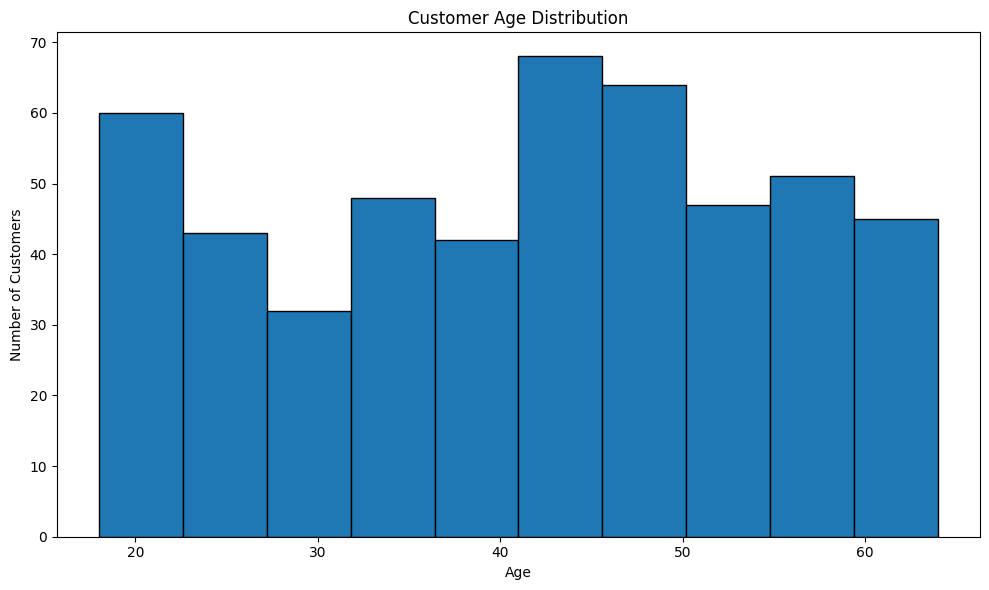

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [14]:
# Count customers by gender
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Male      271
Female    229
Name: count, dtype: int64


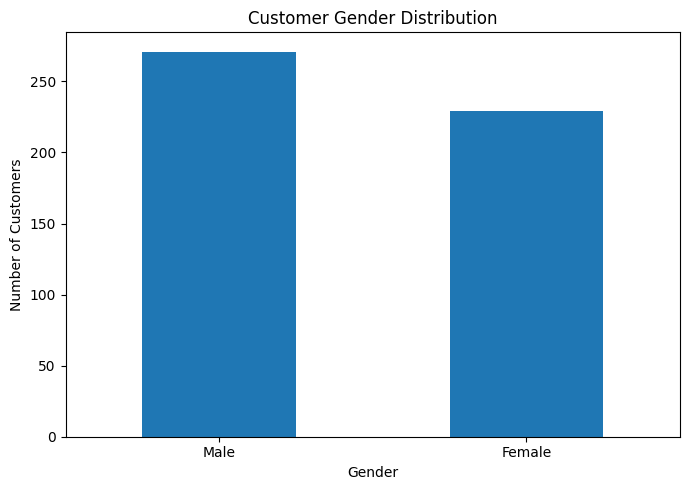

In [15]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# Count customers by city
city_counts = df["City"].value_counts()

print(city_counts)

City
Pune         97
Bengaluru    86
Delhi        83
Hyderabad    80
Mumbai       79
Chennai      75
Name: count, dtype: int64


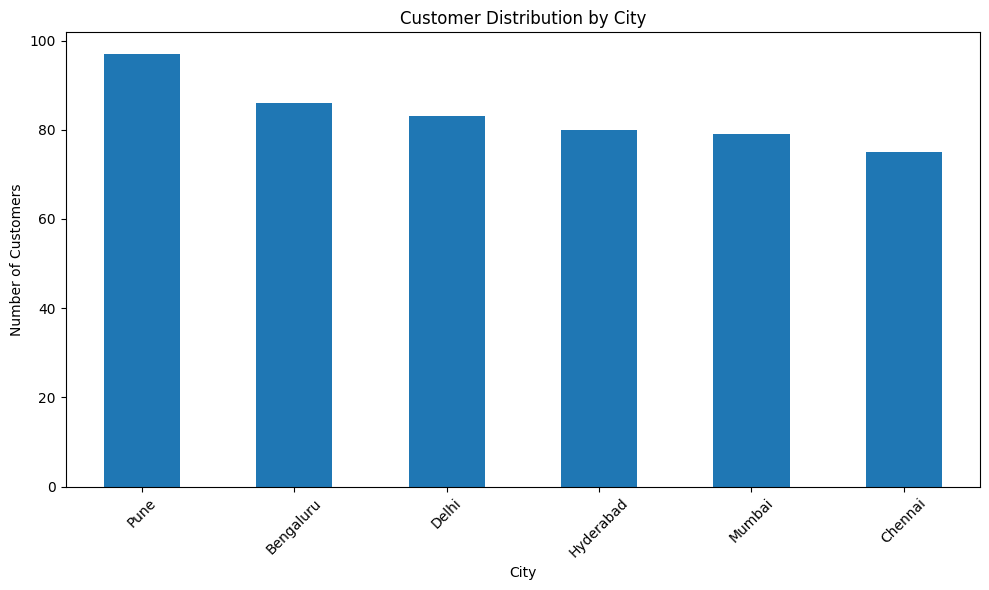

In [18]:
plt.figure(figsize=(10, 6))

city_counts.plot(kind="bar")

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
occupation_counts = df["Occupation"].value_counts()

print(occupation_counts)

Occupation
Teacher     92
Doctor      91
Student     85
Engineer    83
Other       75
Business    74
Name: count, dtype: int64


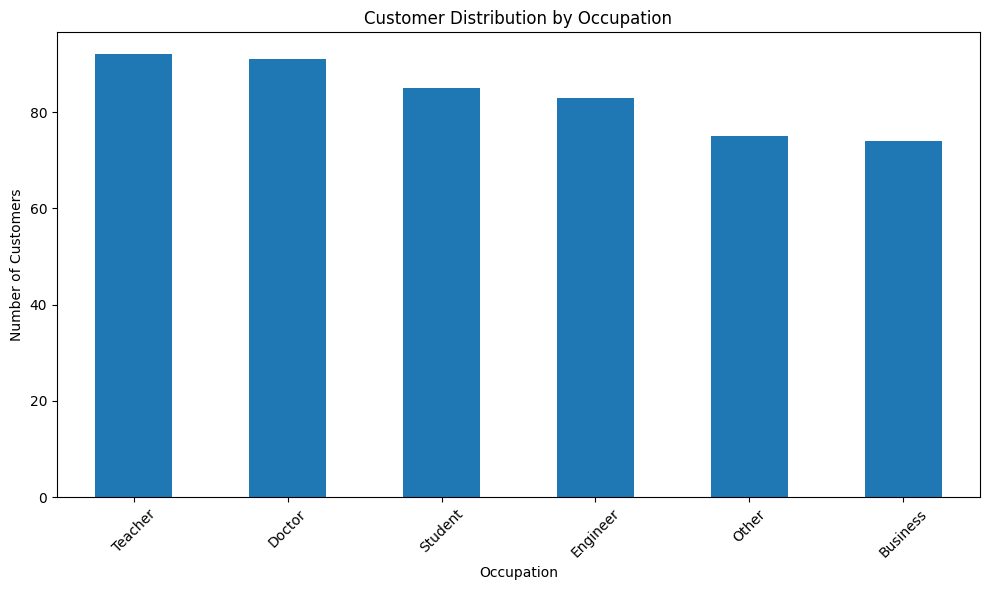

In [20]:
plt.figure(figsize=(10, 6))

occupation_counts.plot(kind="bar")

plt.title("Customer Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
print("Average Annual Income:", df["Annual_Income"].mean())
print("Minimum Annual Income:", df["Annual_Income"].min())
print("Maximum Annual Income:", df["Annual_Income"].max())

Average Annual Income: 87226.582
Minimum Annual Income: 20281
Maximum Annual Income: 149824


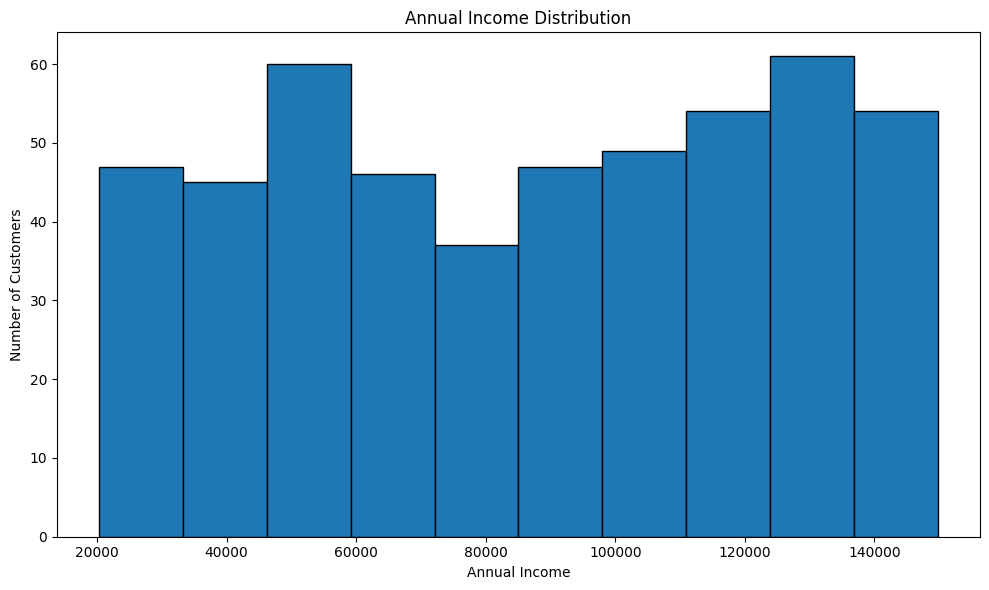

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(df["Annual_Income"], bins=10, edgecolor="black")

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [24]:
print("Average Purchase Frequency:", df["Purchase_Frequency"].mean())
print("Minimum Purchase Frequency:", df["Purchase_Frequency"].min())
print("Maximum Purchase Frequency:", df["Purchase_Frequency"].max())

Average Purchase Frequency: 7.306
Minimum Purchase Frequency: 1
Maximum Purchase Frequency: 14


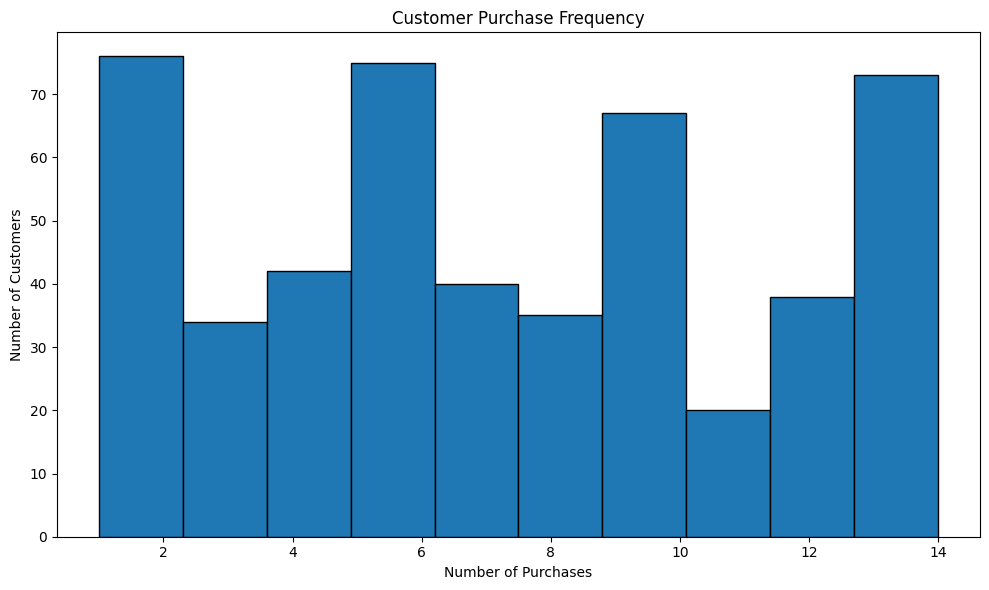

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(df["Purchase_Frequency"], bins=10, edgecolor="black")

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


In [26]:
print("Average Total Spending:", df["Total_Spending"].mean())
print("Minimum Total Spending:", df["Total_Spending"].min())
print("Maximum Total Spending:", df["Total_Spending"].max())

Average Total Spending: 19219.362
Minimum Total Spending: 877
Maximum Total Spending: 63232


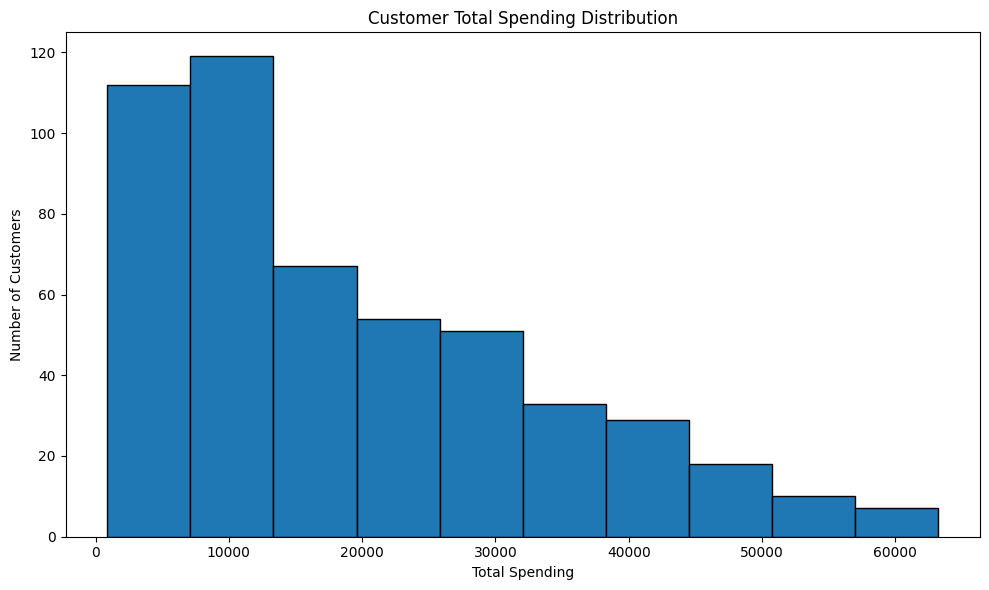

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(df["Total_Spending"], bins=10, edgecolor="black")

plt.title("Customer Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

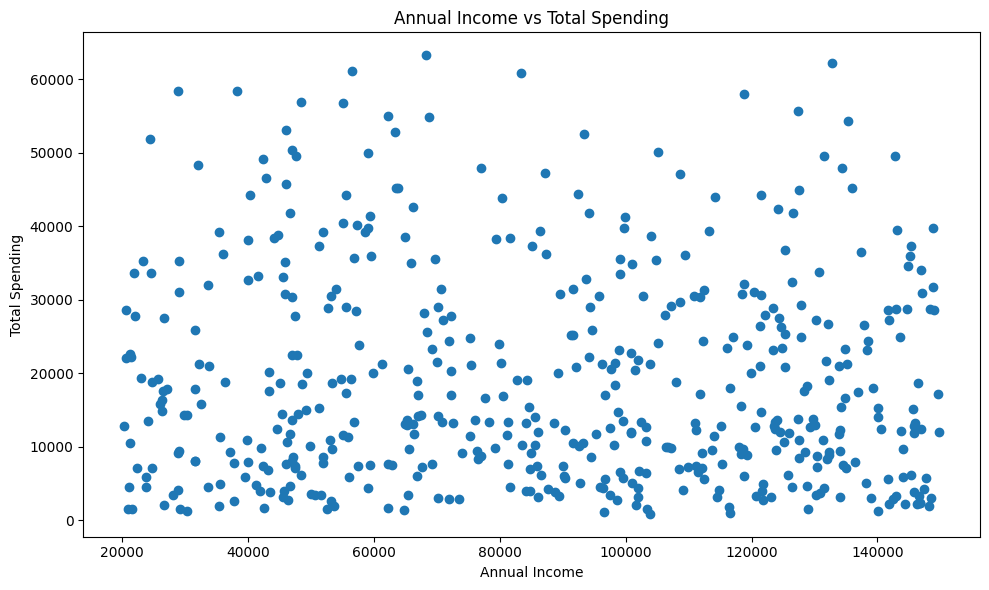

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(df["Annual_Income"], df["Total_Spending"])

plt.title("Annual Income vs Total Spending")
plt.xlabel("Annual Income")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

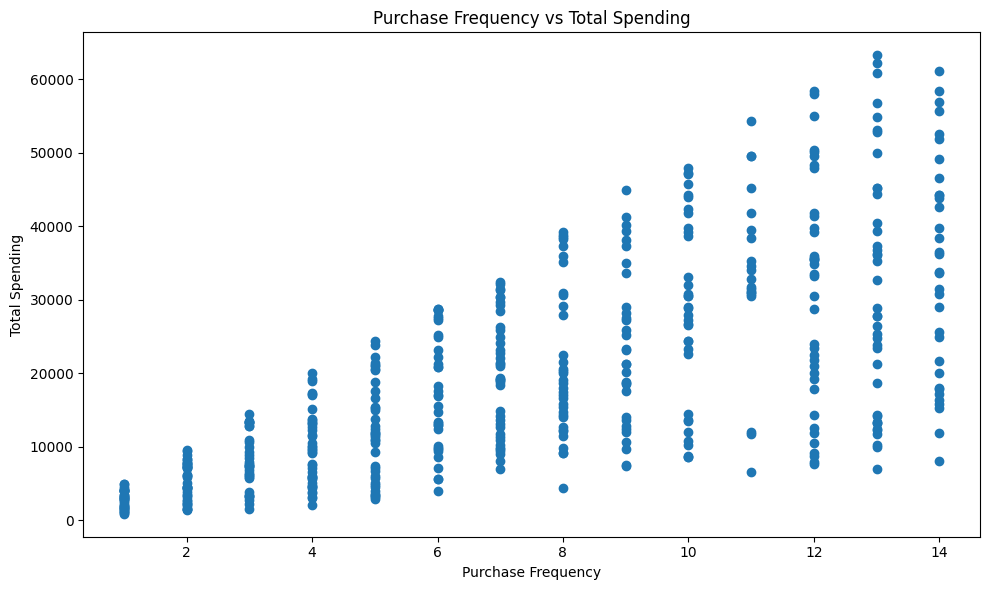

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(df["Purchase_Frequency"], df["Total_Spending"])

plt.title("Purchase Frequency vs Total Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

In [30]:
city_spending = df.groupby("City")["Total_Spending"].sum().sort_values(ascending=False)

print(city_spending)

City
Pune         2049860
Delhi        1637325
Bengaluru    1620948
Chennai      1597039
Mumbai       1428348
Hyderabad    1276161
Name: Total_Spending, dtype: int64


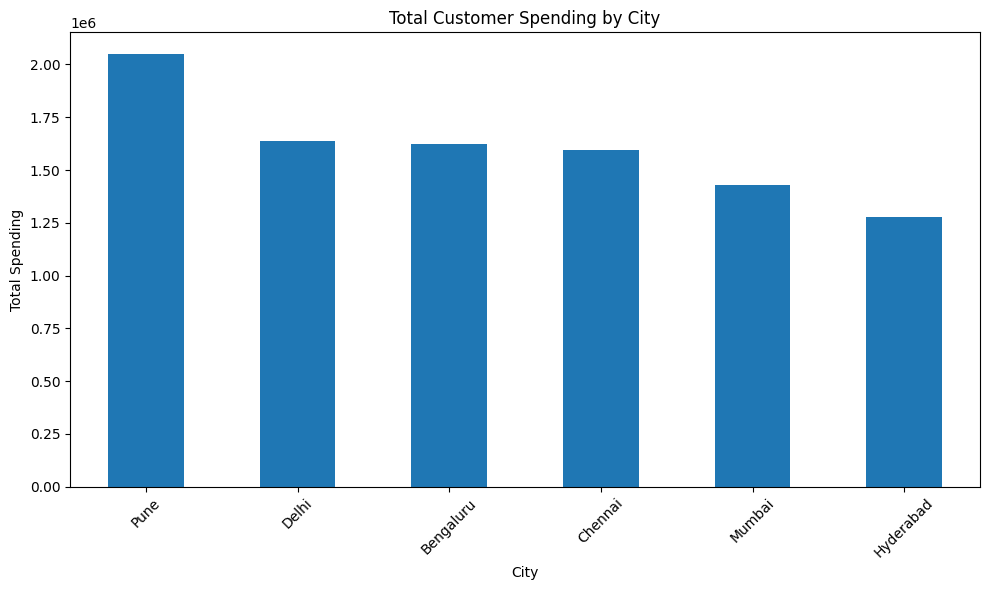

In [31]:
plt.figure(figsize=(10, 6))

city_spending.plot(kind="bar")

plt.title("Total Customer Spending by City")
plt.xlabel("City")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
occupation_spending = df.groupby("Occupation")["Total_Spending"].sum().sort_values(ascending=False)

print(occupation_spending)

Occupation
Engineer    1775944
Doctor      1752768
Teacher     1622482
Student     1570751
Business    1445197
Other       1442539
Name: Total_Spending, dtype: int64


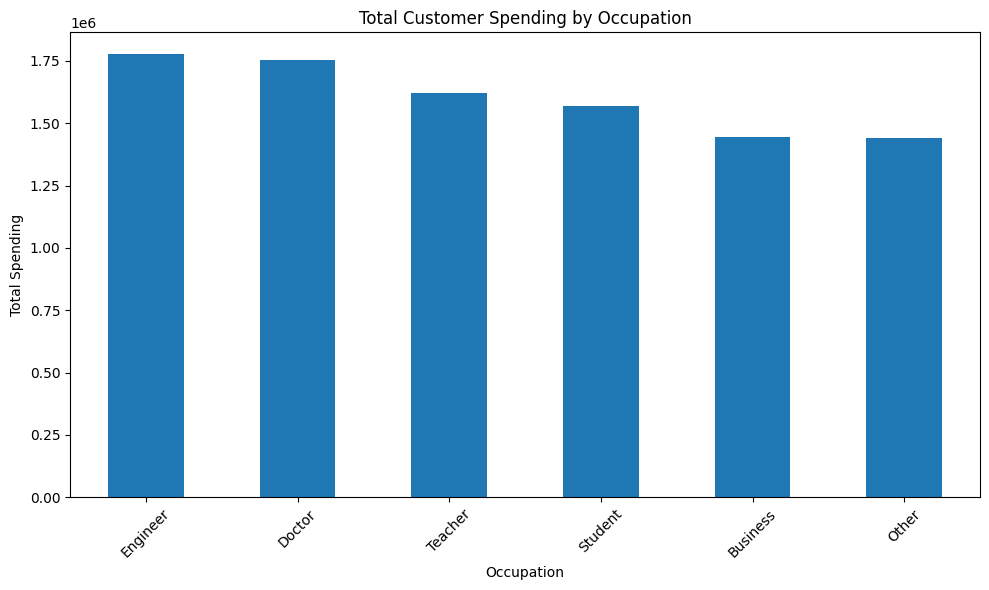

In [35]:
plt.figure(figsize=(10, 6))

occupation_spending.plot(kind="bar")

plt.title("Total Customer Spending by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
total_customers = df["Customer_ID"].nunique()
average_age = df["Age"].mean()
average_income = df["Annual_Income"].mean()
total_spending = df["Total_Spending"].sum()
average_spending = df["Total_Spending"].mean()
average_purchase_frequency = df["Purchase_Frequency"].mean()

print("Total Customers:", total_customers)
print("Average Age:", round(average_age, 2))
print("Average Annual Income:", round(average_income, 2))
print("Total Customer Spending:", round(total_spending, 2))
print("Average Customer Spending:", round(average_spending, 2))
print("Average Purchase Frequency:", round(average_purchase_frequency, 2))

Total Customers: 500
Average Age: 41.28
Average Annual Income: 87226.58
Total Customer Spending: 9609681
Average Customer Spending: 19219.36
Average Purchase Frequency: 7.31


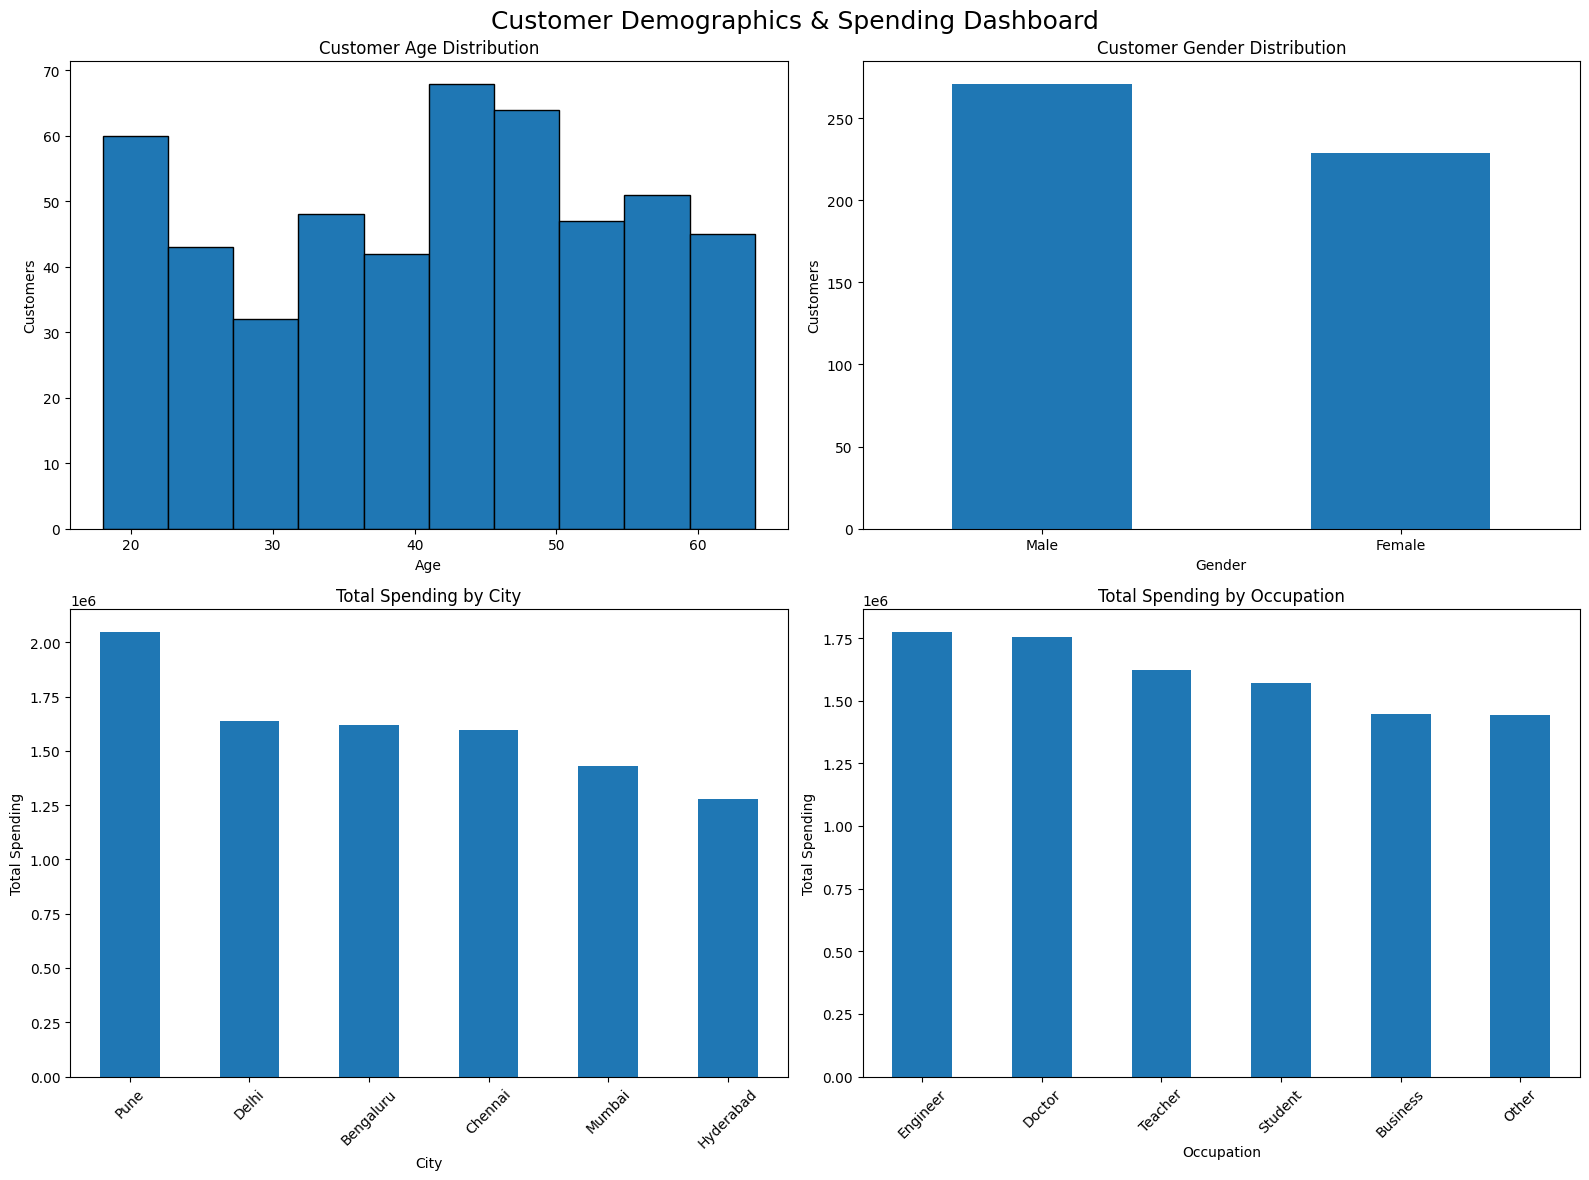

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Age Distribution
axes[0, 0].hist(df["Age"], bins=10, edgecolor="black")
axes[0, 0].set_title("Customer Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Customers")

# 2. Gender Distribution
df["Gender"].value_counts().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Customer Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Customers")
axes[0, 1].tick_params(axis="x", rotation=0)

# 3. City-wise Spending
city_spending = df.groupby("City")["Total_Spending"].sum().sort_values(ascending=False)
city_spending.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Total Spending by City")
axes[1, 0].set_xlabel("City")
axes[1, 0].set_ylabel("Total Spending")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Occupation-wise Spending
occupation_spending = df.groupby("Occupation")["Total_Spending"].sum().sort_values(ascending=False)
occupation_spending.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Total Spending by Occupation")
axes[1, 1].set_xlabel("Occupation")
axes[1, 1].set_ylabel("Total Spending")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.suptitle("Customer Demographics & Spending Dashboard", fontsize=18)
plt.tight_layout()

plt.savefig("customer_demographics_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
KEY INSIGHTS

1. The dataset contains 500 customer records covering different ages, genders, cities, and occupations.

2. Age distribution helps identify the major age groups represented in the customer base.

3. Gender analysis shows the composition of customers based on gender.

4. City-wise analysis identifies locations with a higher number of customers and higher total spending.

5. Occupation-wise analysis shows which professional groups contribute more to customer spending.

6. Annual income analysis provides an understanding of the income levels of customers.

7. Purchase frequency analysis helps identify customer buying patterns.

8. Total spending analysis provides insights into overall customer purchasing behavior.

9. The relationship between annual income and total spending can be studied using the scatter plot.

10. The relationship between purchase frequency and total spending helps understand whether frequent customers tend to spend more.

SyntaxError: invalid syntax (66269409.py, line 1)

In [40]:
from google.colab import files

files.download("customer_demographics_cleaned.csv")
files.download("customer_demographics_dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>